In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
df = pd.read_csv('/content/ecommerce_500k (1).csv')

df.head()

,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25,52.81,1,...,Bangalore,Bronze,0,457.77,4.6,35.0,7.0,0.0,NaN,0.0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10,5.42,3,...,Toronto,Bronze,0,1606.42,2.9,8.0,8.0,0.0,NaN,0.0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20,63.08,2,...,Chicago,Silver,0,252.16,5.5,38.0,8.0,0.0,NaN,0.0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25,43.82,4,...,Sydney,Bronze,0,645.12,6.1,30.0,9.0,0.0,NaN,0.0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15,62.37,1,...,Manchester,Bronze,1,1103.24,1.6,38.0,11.0,0.0,NaN,0.0


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (135927, 30)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135927 entries, 0 to 135926
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 135927 non-null  int64  
 1   customer_id              135927 non-null  int64  
 2   product_id               135927 non-null  int64  
 3   order_date               135927 non-null  object 
 4   category                 135927 non-null  object 
 5   sub_category             135927 non-null  object 
 6   product_base_price       135927 non-null  float64
 7   discount_percentage      135927 non-null  int64  
 8   final_price              135927 non-null  float64
 9   quantity                 135927 non-null  int64  
 10  total_amount             135927 non-null  float64
 11  shipping_cost            131830 non-null  float64
 12  shipping_method          135927 non-null  object 
 13  days_to_deliver          131825 non-null  float64
 14  paym

In [5]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

return_reason              119898
customer_lifetime_value      4158
customer_age                 4138
days_to_deliver              4102
pages_viewed                 4102
shipping_cost                4097
rating                       4072
session_duration_mins        3932
clicks_to_purchase              1
is_returned                     1
is_cancelled                    1
dtype: int64


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df.describe(include='all')

,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
count,1.359270e+05,135927.000000,135927.000000,135927,135927,135927,135927.000000,135927.000000,135927.000000,135927.000000,...,135927,135927,135927.000000,131769.000000,131995.000000,131825.000000,135926.000000,135926.000000,16029,135926.000000
unique,NaN,NaN,NaN,1095,10,45,NaN,NaN,NaN,NaN,...,15,4,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,2023-07-20,Toys,Outdoor,NaN,NaN,NaN,NaN,...,Bangalore,Bronze,NaN,NaN,NaN,NaN,NaN,NaN,Better Price Found,NaN
freq,NaN,NaN,NaN,158,13766,8336,NaN,NaN,NaN,NaN,...,9211,61317,NaN,NaN,NaN,NaN,NaN,NaN,3247,NaN
mean,1.067964e+06,54980.736726,2508.079175,NaN,NaN,NaN,84.886928,14.619281,72.413449,2.282512,...,NaN,NaN,0.278466,849.924235,8.477022,24.992718,10.019709,0.117924,NaN,0.062505
std,3.923889e+04,26057.879535,1443.430703,NaN,NaN,NaN,80.081650,12.952348,69.771700,1.738326,...,NaN,NaN,0.448245,801.803016,8.032687,14.151140,5.470101,0.322520,NaN,0.242071
min,1.000001e+06,10001.000000,1.000000,NaN,NaN,NaN,5.000000,0.000000,2.500000,1.000000,...,NaN,NaN,0.000000,50.020000,0.500000,1.000000,1.000000,0.000000,NaN,0.000000
25%,1.033982e+06,32289.000000,1266.500000,NaN,NaN,NaN,27.880000,5.000000,23.400000,1.000000,...,NaN,NaN,0.000000,280.670000,2.800000,13.000000,5.000000,0.000000,NaN,0.000000
50%,1.067964e+06,55085.000000,2506.000000,NaN,NaN,NaN,60.250000,15.000000,50.490000,2.000000,...,NaN,NaN,0.000000,601.020000,6.000000,25.000000,10.000000,0.000000,NaN,0.000000
75%,1.101946e+06,77546.000000,3763.000000,NaN,NaN,NaN,115.580000,25.000000,98.210000,3.000000,...,NaN,NaN,1.000000,1156.230000,11.600000,37.000000,15.000000,0.000000,NaN,0.000000


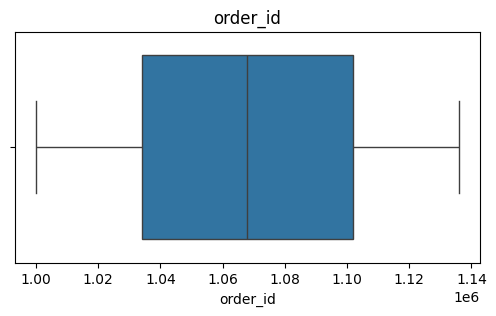

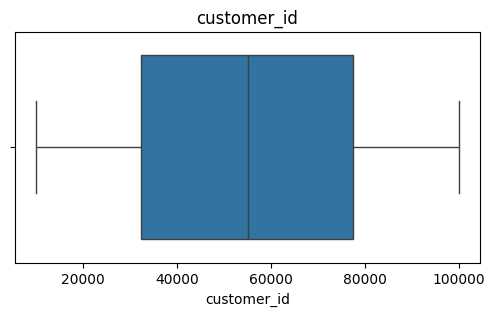

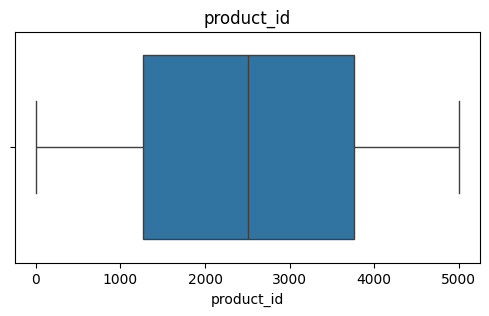

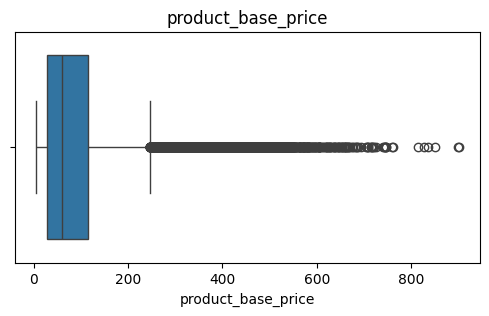

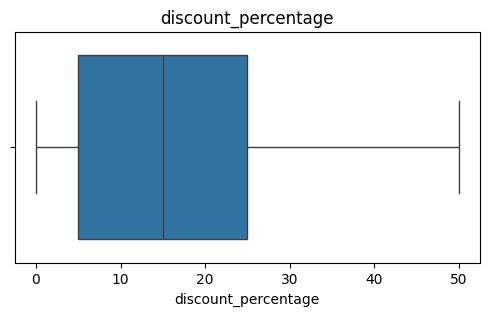

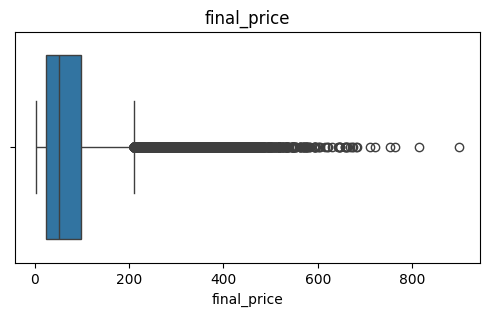

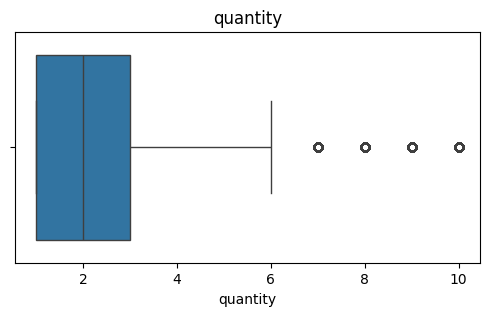

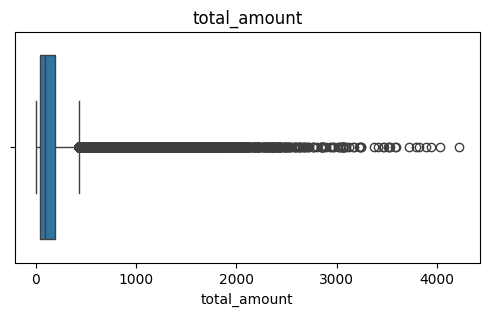

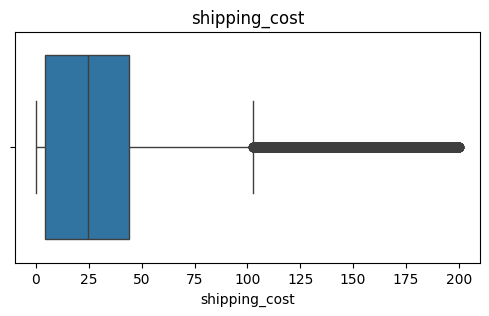

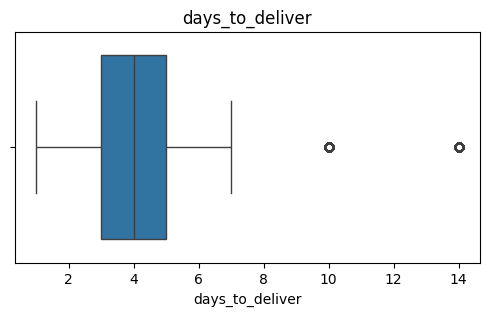

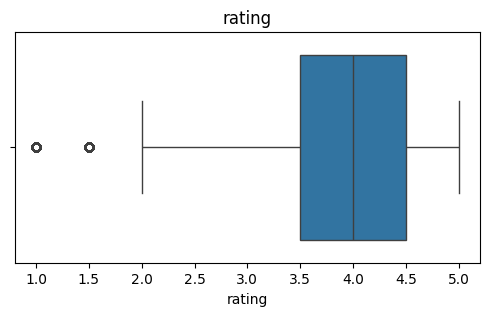

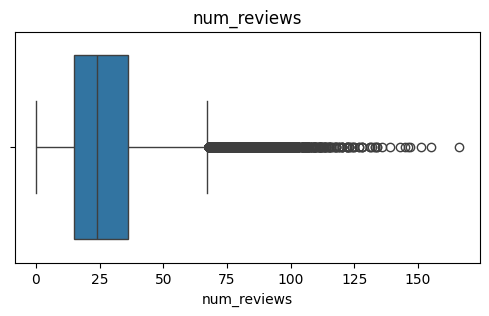

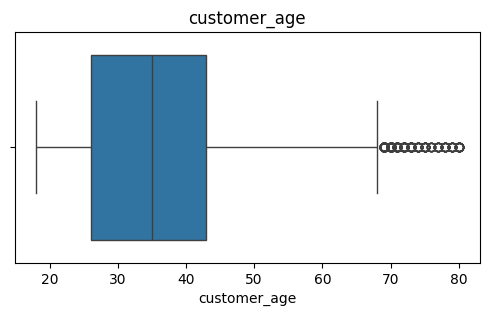

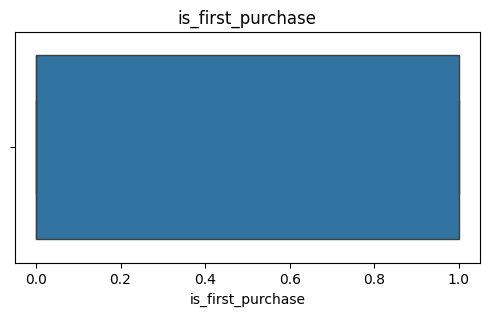

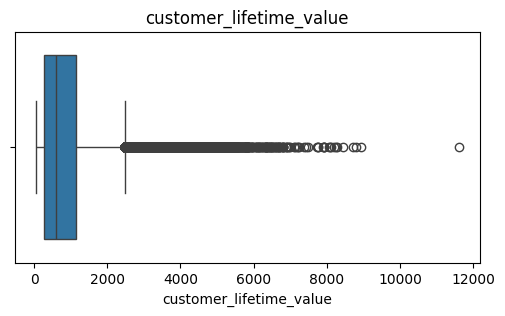

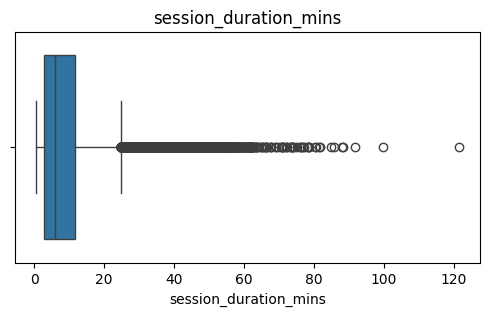

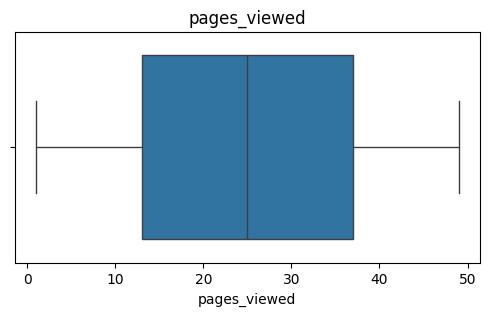

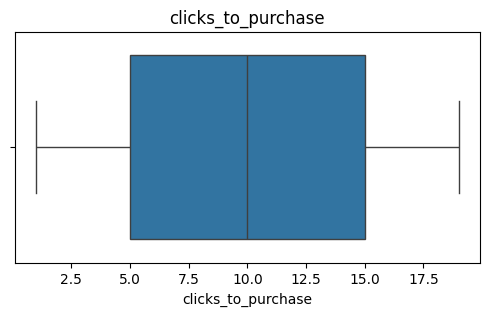

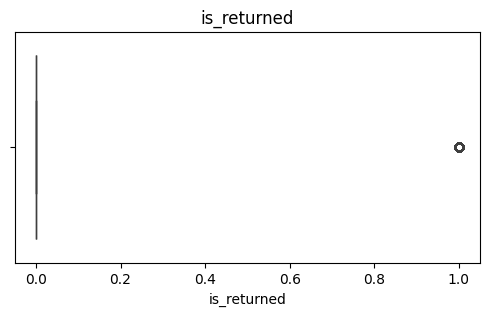

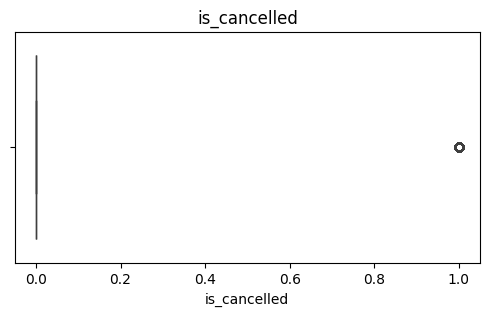

In [8]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

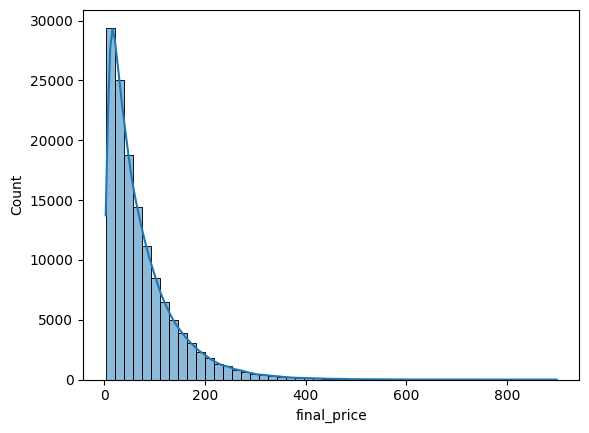

Skewness: 2.0953330875584513


In [11]:
sns.histplot(df['final_price'], bins=50, kde=True)
plt.show()

print("Skewness:", df['final_price'].skew())




In [13]:
print(df.columns.tolist())

['order_id', 'customer_id', 'product_id', 'order_date', 'category', 'sub_category', 'product_base_price', 'discount_percentage', 'final_price', 'quantity', 'total_amount', 'shipping_cost', 'shipping_method', 'days_to_deliver', 'payment_method', 'rating', 'num_reviews', 'customer_age', 'customer_gender', 'country', 'city', 'loyalty_tier', 'is_first_purchase', 'customer_lifetime_value', 'session_duration_mins', 'pages_viewed', 'clicks_to_purchase', 'is_returned', 'return_reason', 'is_cancelled']


In [15]:

cat_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:\n")

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Categorical Columns:

order_date: 1095 unique values
category: 10 unique values
sub_category: 45 unique values
shipping_method: 4 unique values
payment_method: 6 unique values
customer_gender: 3 unique values
country: 8 unique values
city: 15 unique values
loyalty_tier: 4 unique values
return_reason: 5 unique values


In [16]:
cardinality = pd.DataFrame({
    'Column': cat_cols,
    'Unique_Values': [df[col].nunique() for col in cat_cols]
})

cardinality.sort_values(
    by='Unique_Values',
    ascending=False
)

,Column,Unique_Values
0,order_date,1095
2,sub_category,45
7,city,15
1,category,10
6,country,8
4,payment_method,6
9,return_reason,5
3,shipping_method,4
8,loyalty_tier,4
5,customer_gender,3


In [17]:
return_rate = df['is_returned'].mean()*100

print(f"Return Rate: {return_rate:.2f}%")

Return Rate: 11.79%


In [18]:
returns_by_category = pd.crosstab(
    df['category'],
    df['is_returned'],
    normalize='index'
)*100

returns_by_category

is_returned,0.0,1.0
category,,
Automotive,88.298109,11.701891
Beauty,88.045317,11.954683
Books,88.738574,11.261426
Clothing,88.450622,11.549378
Electronics,87.668707,12.331293
Food & Grocery,88.309286,11.690714
Furniture,88.117431,11.882569
Home & Kitchen,88.290155,11.709845
Sports,88.125139,11.874861


In [19]:
returns_by_loyalty = pd.crosstab(
    df['loyalty_tier'],
    df['is_returned'],
    normalize='index'
)*100

returns_by_loyalty

is_returned,0.0,1.0
loyalty_tier,,
Bronze,88.062038,11.937962
Gold,88.337490,11.662510
Platinum,88.274398,11.725602
Silver,88.335307,11.664693


In [20]:
df[df['is_returned']==1]['return_reason'].value_counts()

,count
return_reason,
Better Price Found,3247
Not as Described,3245
Defective,3231
Changed Mind,3160
Wrong Item,3146


In [21]:
shipping_returns = pd.crosstab(
    df['shipping_method'],
    df['is_returned'],
    normalize='index'
)*100

shipping_returns

is_returned,0.0,1.0
shipping_method,,
Express,88.055293,11.944707
Free,88.055923,11.944077
Same-Day,88.299049,11.700951
Standard,88.338911,11.661089


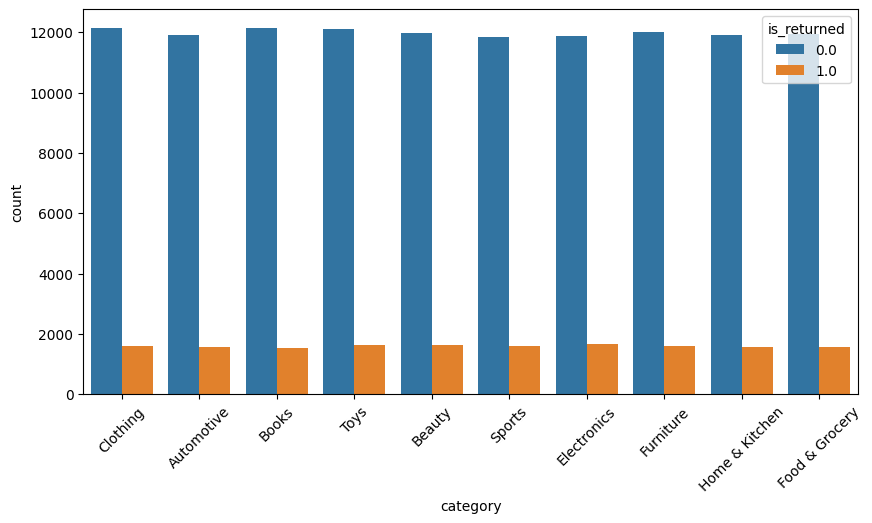

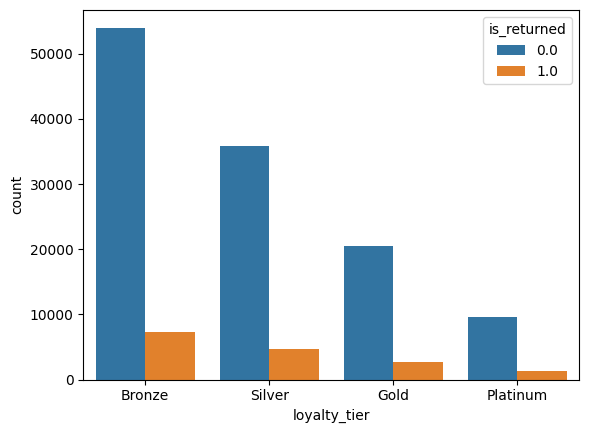

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='category',
    hue='is_returned',
    data=df
)

plt.xticks(rotation=45)
plt.show()

sns.countplot(
    x='loyalty_tier',
    hue='is_returned',
    data=df
)

plt.show()

In [26]:
print(df.columns.tolist())



['order_id', 'customer_id', 'product_id', 'order_date', 'category', 'sub_category', 'product_base_price', 'discount_percentage', 'final_price', 'quantity', 'total_amount', 'shipping_cost', 'shipping_method', 'days_to_deliver', 'payment_method', 'rating', 'num_reviews', 'customer_age', 'customer_gender', 'country', 'city', 'loyalty_tier', 'is_first_purchase', 'customer_lifetime_value', 'session_duration_mins', 'pages_viewed', 'clicks_to_purchase', 'is_returned', 'return_reason', 'is_cancelled']


In [27]:
[col for col in df.columns if 'discount' in col.lower()]

['discount_percentage']

In [28]:
df['price_per_item'] = (
    df['total_amount']
    / df['quantity']
)

df['engagement_score'] = (
    df['pages_viewed']
    + df['clicks_to_purchase']
)

df['high_value_customer'] = (
    df['customer_lifetime_value']
    >
    df['customer_lifetime_value'].median()
).astype(int)

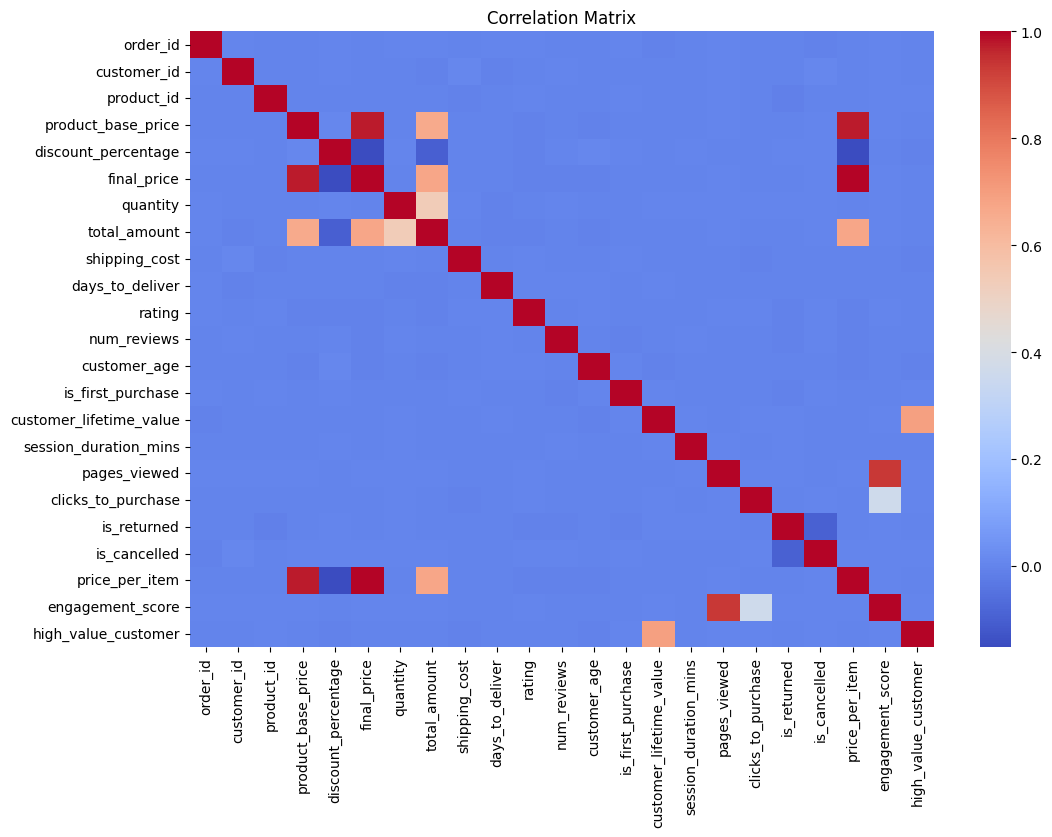

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [30]:
corr = df.corr(numeric_only=True)

corr['is_returned'].sort_values(
    ascending=False
)

,is_returned
is_returned,1.000000
quantity,0.002671
customer_lifetime_value,0.001916
discount_percentage,0.001740
session_duration_mins,0.001530
pages_viewed,0.001007
engagement_score,0.000684
clicks_to_purchase,0.000117
customer_age,-0.000212
final_price,-0.000403


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [32]:
X = df.select_dtypes(
    include='number'
).drop(
    columns=['is_returned']
)

y = df['is_returned']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
df['is_returned'].isna().sum()

np.int64(1)

In [36]:
df = df.dropna(subset=['is_returned'])

In [37]:
print(df['is_returned'].isna().sum())


0


In [38]:
X = df.select_dtypes(include='number').drop(columns=['is_returned'])
y = df['is_returned']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
14,customer_lifetime_value,0.069460
0,order_id,0.066528
1,customer_id,0.065725
2,product_id,0.065203
15,session_duration_mins,0.062520
7,total_amount,0.061058
8,shipping_cost,0.059807
3,product_base_price,0.058520
19,price_per_item,0.055602
5,final_price,0.055265


In [41]:
from sklearn.metrics import accuracy_score

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8799014198484514
